In [7]:
from pathlib import Path
from typing import List, Dict, Optional
import torch
from PIL import Image

import sys 
sys.path.append(".")
sys.path.append("..")

from poisson_pipeline import StormPipeline
from config import RunConfig
from run import run_on_prompt, get_indices_to_alter
from utils import vis_utils
from utils.ptp_utils import AttentionStore

# %load_ext autoreload 
# %autoreload 2

# Load Model Weights

In [8]:
NUM_DIFFUSION_STEPS = 50
GUIDANCE_SCALE = 7.5
MAX_NUM_WORDS = 77
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
stable = StormPipeline.from_pretrained("CompVis/stable-diffusion-v1-4").to(device)
tokenizer = stable.tokenizer

text_encoder/pytorch_model.fp16.safetensors not found


Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

The config attributes {'scaling_factor': 0.18215} were passed to AutoencoderKL, but are not expected and will be ignored. Please verify your config.json configuration file.


# Pipeline Wrapper

In [9]:
import numpy as np
print(np.__version__)
import torch
print(torch.__version__)
x = np.array([1, 2, 3])
t = torch.from_numpy(x)
print(t)  # should print tensor([1, 2, 3])

1.26.4
2.1.0+cu118
tensor([1, 2, 3])


In [10]:
def run_and_display(prompts: List[str],
                    controller: AttentionStore,
                    indices_to_alter: List[int],
                    generator: torch.Generator,
                    run_standard_sd: bool = False,
                    scale_factor: int = 20,
                    thresholds: Dict[int, float] = {0:0.05, 10: 0.5, 20: 0.8},
                    max_iter_to_alter: int = 25,
                    display_output: bool = False,
                    sd_2_1: bool = False,
                    save_attn_snapshots: bool = False,
                    attn_snapshot_steps: Optional[List[int]] = None,
                    attn_snapshot_base_dir: Optional[Path] = None,
                    attn_snapshot_token_indices: Optional[List[int]] = None,
                    display_attention_maps: bool = False):
    config = RunConfig(run_standard_sd=run_standard_sd,
                       scale_factor=scale_factor,
                       thresholds=thresholds,
                       max_iter_to_alter=max_iter_to_alter,
                       sd_2_1=sd_2_1,
                       save_attn_snapshots=save_attn_snapshots,
                       attn_snapshot_steps=attn_snapshot_steps or [0, 10, 17, 25, 35],
                       attn_snapshot_base_dir=attn_snapshot_base_dir,
                       attn_snapshot_token_indices=attn_snapshot_token_indices,
                       display_attention_maps=display_attention_maps)
    image = run_on_prompt(model=stable,
                          prompt=prompts,
                          controller=controller,
                          token_indices=indices_to_alter,
                          seed=generator,
                          config=config)
    if display_output:
        display(image)
    return image

In [13]:
def generate_images_for_method(prompt: str,
                               seeds: List[int],
                               indices_to_alter: Optional[List[int]] = None,
                               is_storm_true: bool = True,
                               sd_2_1: bool = False,
                               save_attn_snapshots: bool = False,
                               attn_snapshot_steps: Optional[List[int]] = None,
                               attn_snapshot_base_dir: Optional[Path] = None,
                               attn_snapshot_token_indices: Optional[List[int]] = None,
                               display_attention_maps: bool = False,
                               visualize_attention: bool = False):
    token_indices = get_indices_to_alter(stable, prompt) if indices_to_alter is None else indices_to_alter
    images = []
    for seed in seeds:
        g = torch.Generator('cuda').manual_seed(seed)
        prompts = [prompt]
        controller = AttentionStore()
        run_standard_sd = False if is_storm_true else True

        seed_snapshot_dir = None
        if save_attn_snapshots:
            if is_storm_true:
                method_dir = "storm"
            else:
                method_dir = "traditional_sd"

            base_root = attn_snapshot_base_dir or Path("./output/attn_progress_notebook")
            seed_snapshot_dir = base_root / method_dir / prompt / f"seed_{seed}"

        image = run_and_display(prompts=prompts,
                                controller=controller,
                                indices_to_alter=token_indices,
                                generator=g,
                                run_standard_sd=run_standard_sd,
                                sd_2_1=sd_2_1,
                                save_attn_snapshots=save_attn_snapshots,
                                attn_snapshot_steps=attn_snapshot_steps,
                                attn_snapshot_base_dir=seed_snapshot_dir,
                                attn_snapshot_token_indices=attn_snapshot_token_indices,
                                display_attention_maps=display_attention_maps)
        images.append(image.resize((256, 256)))
        if visualize_attention:                          # <-- add this block
            from utils.vis_utils import visualize_cross_attention_maps
            grid = visualize_cross_attention_maps(
                prompt=prompt,                           # local var ✓
                attention_store=controller,              # local var ✓
                tokenizer=stable.tokenizer,
                token_indices=[i for sub in token_indices
                            for i in sub if i is not None],  # flatten [[3,9],[2,None]] → [3,9,2]
                orig_image=image,                        # local var ✓
                save_path=f"./attention_vis/seed_{seed}.png",
                display_image=True,
            )
        if save_attn_snapshots and seed_snapshot_dir is not None and seed_snapshot_dir.exists():
            step_files = sorted(seed_snapshot_dir.glob("step_*.png"))
            if step_files:
                print(f"Saved attention maps for seed {seed} in {seed_snapshot_dir}")
                display([Image.open(p) for p in step_files])

    grid = vis_utils.get_image_grid(images)
    display(grid)

# Stable Diffusion

  0%|          | 0/50 [00:00<?, ?it/s]

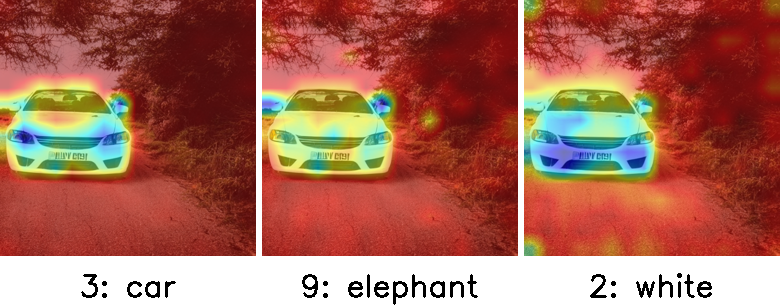

  0%|          | 0/50 [00:00<?, ?it/s]

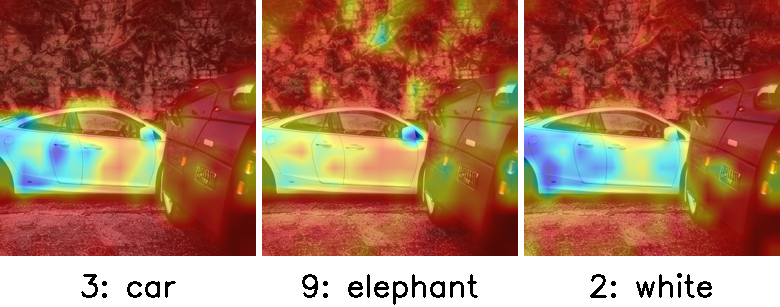

  0%|          | 0/50 [00:00<?, ?it/s]

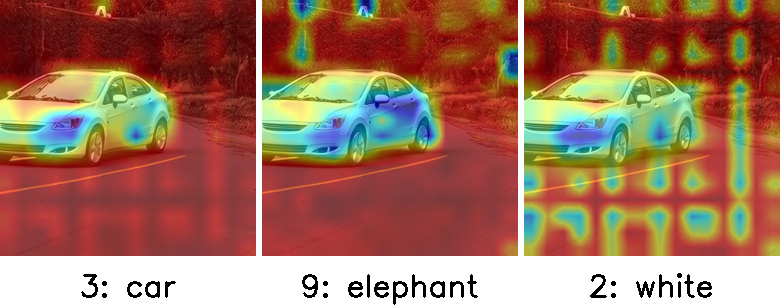

  0%|          | 0/50 [00:00<?, ?it/s]

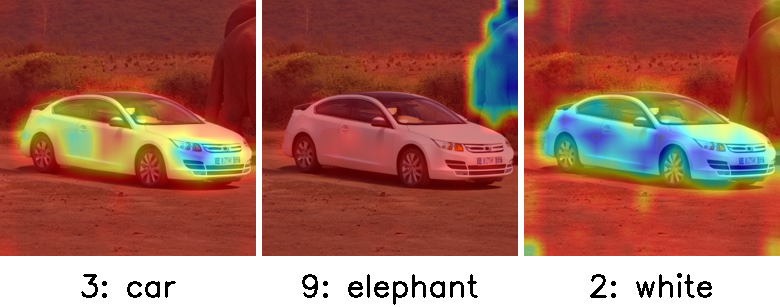

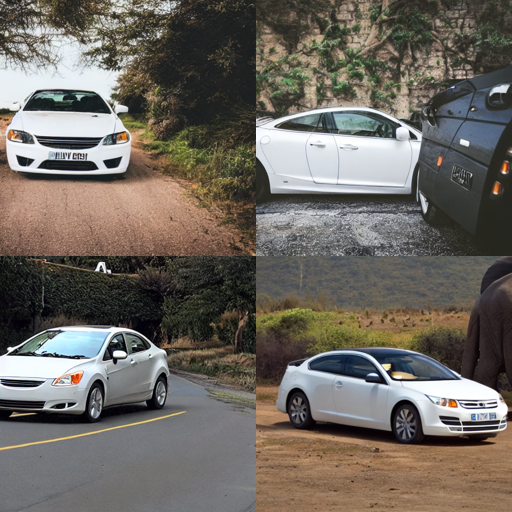

In [14]:
generate_images_for_method(
    prompt="a white car to the left of an elephant",
    indices_to_alter = ([3, 9], [2, None]),
    seeds=[6143, 7792, 8892, 9010],
    is_storm_true=False,
    visualize_attention=True
)

# STORM

  0%|          | 0/50 [00:00<?, ?it/s]

Iteration 1 | Loss: 1.1412
Iteration 2 | Loss: 1.2280
Iteration 3 | Loss: 1.3014
Iteration 4 | Loss: 0.8731
Iteration 5 | Loss: 0.5582
Iteration 6 | Loss: 0.4967
Iteration 7 | Loss: 0.5026
Iteration 8 | Loss: 0.4816
Iteration 9 | Loss: 0.4069
Iteration 10 | Loss: 0.4353
Iteration 11 | Loss: 0.3767
Iteration 12 | Loss: 0.4107
Iteration 13 | Loss: 0.3455
Iteration 14 | Loss: 0.3631
Iteration 15 | Loss: 0.3295
Iteration 16 | Loss: 0.3459
Iteration 17 | Loss: 0.4044
Iteration 18 | Loss: 0.4071
Iteration 19 | Loss: 0.3223
Iteration 20 | Loss: 0.1970
Iteration 21 | Loss: 0.2076
Iteration 22 | Loss: 0.2010
Iteration 23 | Loss: 0.2107
Iteration 24 | Loss: 0.2088


  0%|          | 0/50 [00:00<?, ?it/s]

Iteration 1 | Loss: 0.9285
Iteration 2 | Loss: 1.2613
Iteration 3 | Loss: 1.0197
Iteration 4 | Loss: 0.6750
Iteration 5 | Loss: 0.6217
Iteration 6 | Loss: 0.5561
Iteration 7 | Loss: 0.5426
Iteration 8 | Loss: 0.5751
Iteration 9 | Loss: 0.5470
Iteration 10 | Loss: 0.4851
Iteration 11 | Loss: 0.4663
Iteration 12 | Loss: 0.4466
Iteration 13 | Loss: 0.4178
Iteration 14 | Loss: 0.4071
Iteration 15 | Loss: 0.4002
Iteration 16 | Loss: 0.3971
Iteration 17 | Loss: 0.4017
Iteration 18 | Loss: 0.3909
Iteration 19 | Loss: 0.3860
	 Exceeded max refinement steps (30)!
Iteration 20 | Loss: 0.2314
Iteration 21 | Loss: 0.2343
Iteration 22 | Loss: 0.3004
Iteration 23 | Loss: 0.2767
Iteration 24 | Loss: 0.3220


  0%|          | 0/50 [00:00<?, ?it/s]

Iteration 1 | Loss: 1.4010
Iteration 2 | Loss: 1.8138
Iteration 3 | Loss: 0.7286
Iteration 4 | Loss: 0.5105
Iteration 5 | Loss: 0.5877
Iteration 6 | Loss: 0.5502
Iteration 7 | Loss: 0.5388
Iteration 8 | Loss: 0.4372
Iteration 9 | Loss: 0.6090
Iteration 10 | Loss: 0.4141
Iteration 11 | Loss: 0.6864
Iteration 12 | Loss: 0.4310
Iteration 13 | Loss: 0.3856
Iteration 14 | Loss: 0.3638
Iteration 15 | Loss: 0.3485
Iteration 16 | Loss: 0.3366
Iteration 17 | Loss: 0.3308
Iteration 18 | Loss: 0.3316
Iteration 19 | Loss: 0.3347
Iteration 20 | Loss: 0.1956
Iteration 21 | Loss: 0.2741
Iteration 22 | Loss: 0.2097
Iteration 23 | Loss: 0.2653
Iteration 24 | Loss: 0.2357


  0%|          | 0/50 [00:00<?, ?it/s]

Iteration 1 | Loss: 2.3436
Iteration 2 | Loss: 2.7701
Iteration 3 | Loss: 0.7602
Iteration 4 | Loss: 0.5249
Iteration 5 | Loss: 0.4616
Iteration 6 | Loss: 0.4224
Iteration 7 | Loss: 0.4820
Iteration 8 | Loss: 0.4474
Iteration 9 | Loss: 0.4228
Iteration 10 | Loss: 0.4083
Iteration 11 | Loss: 0.4361
Iteration 12 | Loss: 0.4127
Iteration 13 | Loss: 0.4569
Iteration 14 | Loss: 0.4249
Iteration 15 | Loss: 0.4034
Iteration 16 | Loss: 0.3907
Iteration 17 | Loss: 0.3720
Iteration 18 | Loss: 0.3907
Iteration 19 | Loss: 0.3885
	 Exceeded max refinement steps (30)!
Iteration 20 | Loss: 0.2363
Iteration 21 | Loss: 0.2848
Iteration 22 | Loss: 0.2491
Iteration 23 | Loss: 0.3009
Iteration 24 | Loss: 0.2704


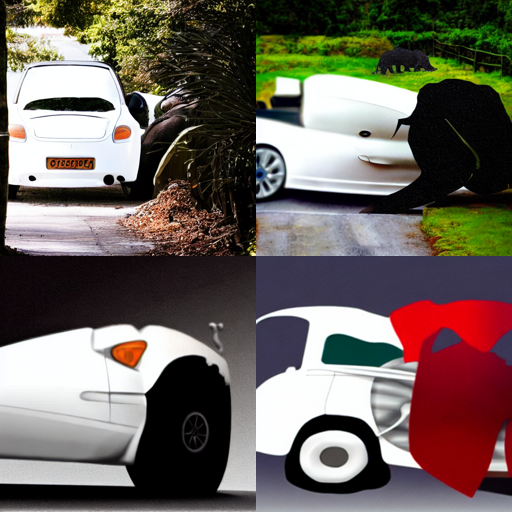

In [ ]:
generate_images_for_method(
    prompt="a white car to the left of an elephant",
    indices_to_alter = ([3, 9], [2, None]),
    seeds=[6143, 7792, 8892, 9010],
    is_storm_true=True,
    visualize_attention=True
)

In [ ]:
from utils.vis_utils import visualize_cross_attention_maps

# After generation:
grid = visualize_cross_attention_maps(
    prompt=prompt,                        # your prompt string
    attention_store=controller,           # the AttentionStore used during generation
    tokenizer=stable.tokenizer,
    res=16,                               # matches attention_res in pipeline
    from_where=["up", "down", "mid"],
    token_indices=token_indices,          # the indices you already computed
    orig_image=image,                     # the generated PIL image (for overlay)
    save_path="./attention_vis/out.png",  # optional
    display_image=True,
)
display(grid)